In [41]:
import numpy
import pandas

import matplotlib.pyplot as pyplot
import seaborn

In [42]:
data = pandas.read_csv("TSLA.csv")

cierre = data["Close"]

cierre.head()

0    16.058001
1    16.312668
2    16.208668
3    15.535333
4    15.428667
Name: Close, dtype: float64

<Axes: >

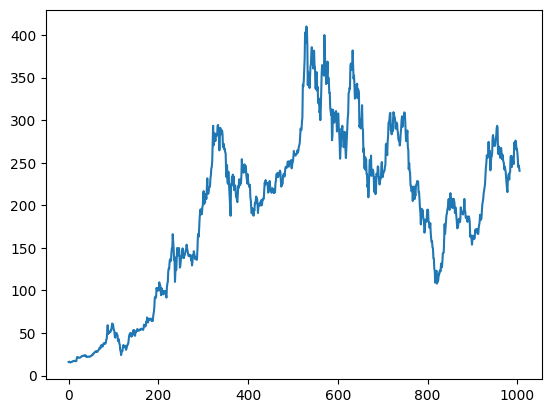

In [43]:
cierre.plot()

In [78]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import (
    DecisionTreeRegressor,
    plot_tree
)

In [45]:
X = numpy.array(cierre.index).reshape((-1, 1))
y = cierre.values

X[:5], y[:5]

(array([[0],
        [1],
        [2],
        [3],
        [4]]),
 array([16.058001, 16.312668, 16.208668, 15.535333, 15.428667]))

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((804, 1), (202, 1), (804,), (202,))

In [47]:
modelo = DecisionTreeRegressor(
    max_depth=3, criterion="squared_error")

modelo.fit(X_train, y_train)

modelo

DecisionTreeRegressor(max_depth=3)

In [80]:
y_pred = modelo.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

pandas.DataFrame({
    "MSE": [mse],
    "MAE": [mae],
    "R^2": [r2],
}, index=["Valor"]).T

,Valor
MSE,1019.400682
MAE,21.662560
R^2,0.891823


Text(0, 0.5, 'Valor de la acción (dólares)')

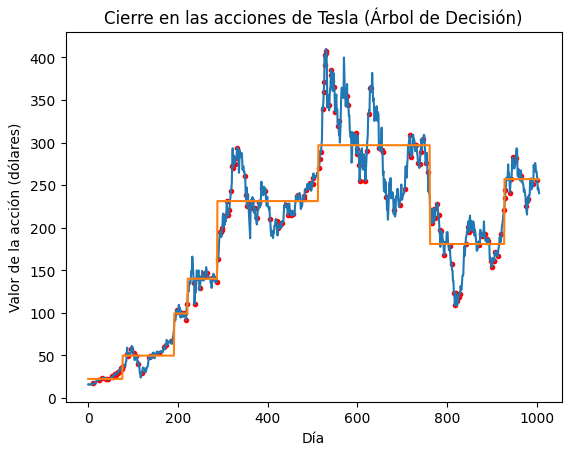

In [76]:
y_plot = modelo.predict(X)

pyplot.scatter(X_test, y_test, color="red", marker=".")
pandas.Series(y).plot()
pandas.Series(y_plot).plot()
pyplot.title("Cierre en las acciones de Tesla (Árbol de Decisión)")
pyplot.xlabel("Día")
pyplot.ylabel("Valor de la acción (dólares)")

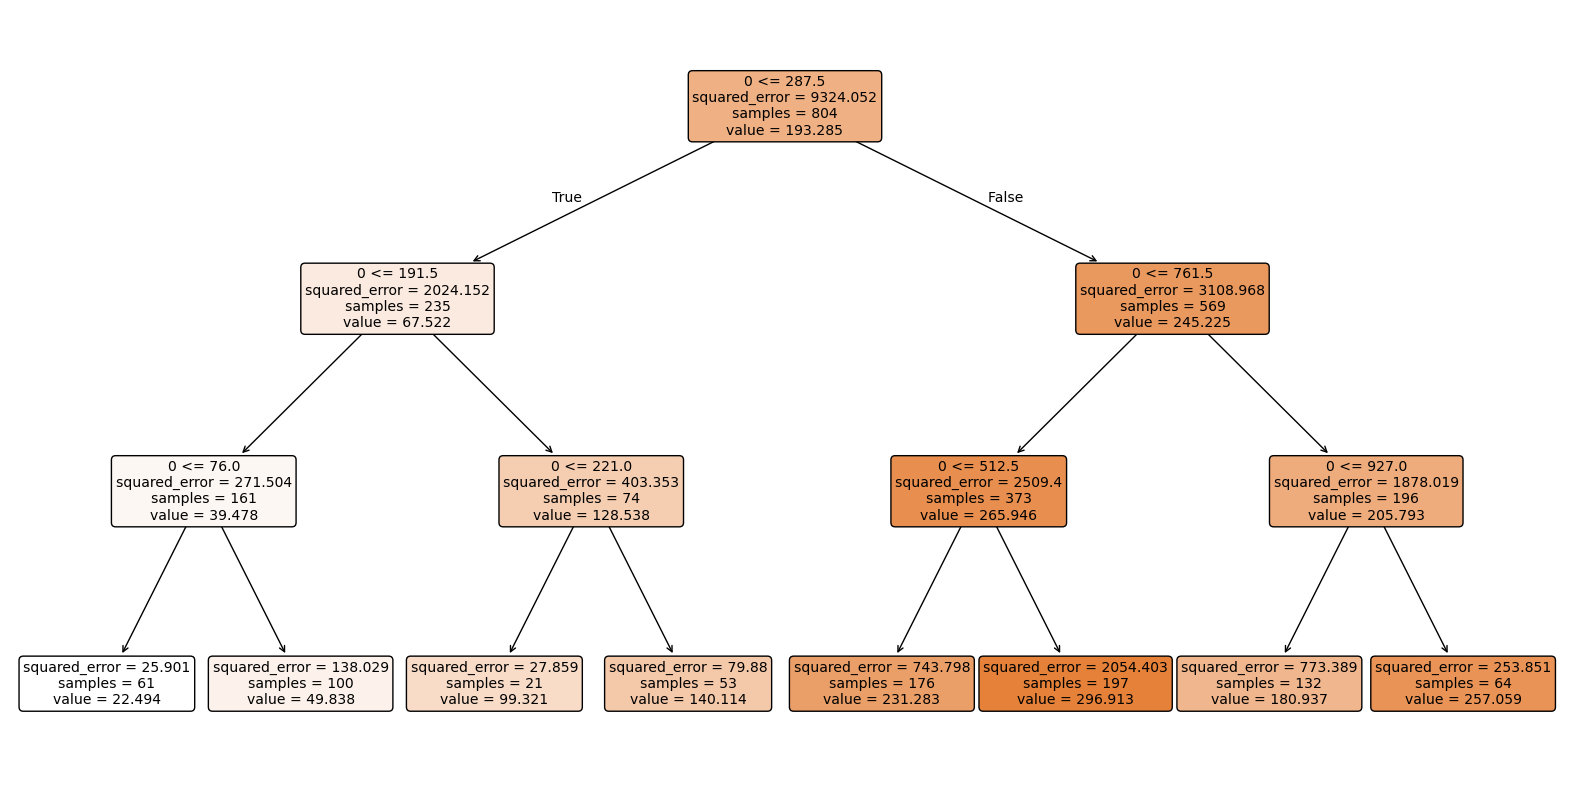

In [70]:
pyplot.figure(figsize=(20, 10))
plot_tree(modelo, filled=True, feature_names=cierre.index, rounded=True)
pyplot.show()

## Bosques Aleatorios

In [72]:
from sklearn.ensemble import RandomForestRegressor

In [73]:
modelo2 = RandomForestRegressor(
    n_estimators=100, random_state=42, criterion="squared_error")

modelo2.fit(X_train, y_train)

modelo2

RandomForestRegressor(random_state=42)

In [81]:
y_pred2 = modelo2.predict(X_test)

mse2 = mean_squared_error(y_test, y_pred2)
mae2 = mean_absolute_error(y_test, y_pred2)
r22 = r2_score(y_test, y_pred2)

pandas.DataFrame({
    "MSE": [mse],
    "MAE": [mae],
    "R^2": [r22],
}, index=["Valor"]).T

,Valor
MSE,1019.400682
MAE,21.662560
R^2,0.994600


Text(0, 0.5, 'Valor de la acción (dólares)')

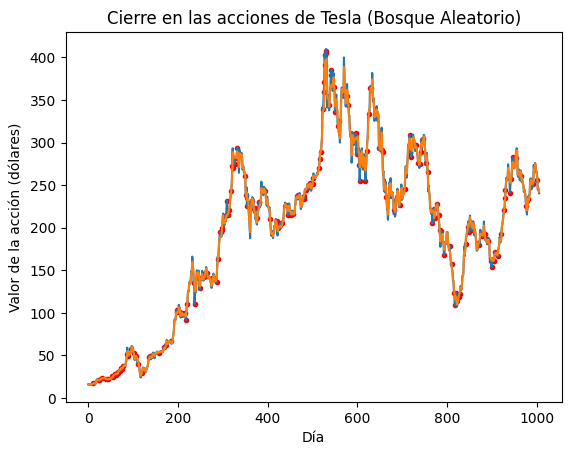

In [77]:
y_plot2 = modelo2.predict(X)

pyplot.scatter(X_test, y_test, color="red", marker=".")
pandas.Series(y).plot()
pandas.Series(y_plot2).plot()
pyplot.title("Cierre en las acciones de Tesla (Bosque Aleatorio)")
pyplot.xlabel("Día")
pyplot.ylabel("Valor de la acción (dólares)")

## Análisis RAMA

In [85]:
rama = pandas.read_csv("rama_2019.csv").drop(columns=["fecha"])

rama.head()

,CO,NO,NO2,NOX,O3,PM10,PM25,SO2
0,0.642419,12.617143,22.363946,35.441905,38.940387,93.458586,63.278607,4.616041
1,0.533982,18.812081,29.930827,49.379195,23.565789,63.889813,33.844221,7.147321
2,0.715211,33.603041,38.135542,72.822635,24.922164,65.099404,27.566586,4.555878
3,0.656344,28.825127,35.659542,65.322581,31.628838,66.979879,30.995074,3.610370
4,0.547734,18.575552,32.806354,52.078098,36.803170,69.781676,35.745843,5.655977


In [87]:
rama.corr()

,CO,NO,NO2,NOX,O3,PM10,PM25,SO2
CO,1.000000,0.869625,0.868840,0.932767,-0.202840,0.532978,0.394015,0.217151
NO,0.869625,1.000000,0.732459,0.949729,-0.346806,0.397130,0.137543,0.174872
NO2,0.868840,0.732459,1.000000,0.908279,-0.045337,0.635942,0.486449,0.314325
NOX,0.932767,0.949729,0.908279,1.000000,-0.230229,0.535934,0.307431,0.250157
O3,-0.202840,-0.346806,-0.045337,-0.230229,1.000000,0.481361,0.519439,-0.124588
PM10,0.532978,0.397130,0.635942,0.535934,0.481361,1.000000,0.878608,0.363953
PM25,0.394015,0.137543,0.486449,0.307431,0.519439,0.878608,1.000000,0.315615
SO2,0.217151,0.174872,0.314325,0.250157,-0.124588,0.363953,0.315615,1.000000


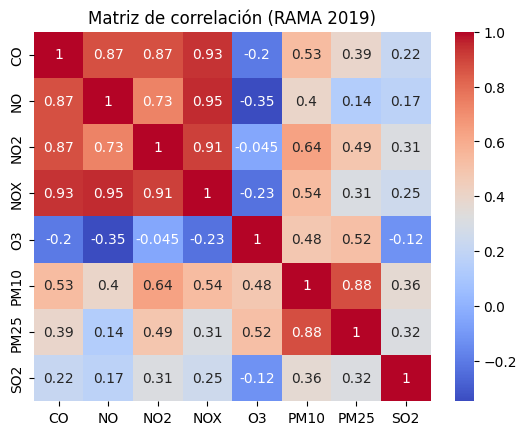

In [92]:
seaborn.heatmap(rama.corr(), cmap="coolwarm", annot=True)
pyplot.title("Matriz de correlación (RAMA 2019)")
pyplot.show()

In [93]:
X = rama.drop(columns=["PM25"]).values
y = rama["PM25"]

X[:5], y[:5]

(array([[ 0.64241908, 12.61714286, 22.36394558, 35.44190476, 38.94038748,
         93.45858586,  4.61604096],
        [ 0.53398204, 18.81208054, 29.93082707, 49.37919463, 23.56578947,
         63.88981289,  7.14732143],
        [ 0.71521084, 33.60304054, 38.13554217, 72.82263514, 24.92216359,
         65.09940358,  4.55587808],
        [ 0.65634441, 28.82512733, 35.65954198, 65.32258065, 31.62883845,
         66.97987928,  3.61037037],
        [ 0.54773414, 18.57555178, 32.80635401, 52.07809847, 36.80317041,
         69.78167641,  5.65597668]]),
 0    63.278607
 1    33.844221
 2    27.566586
 3    30.995074
 4    35.745843
 Name: PM25, dtype: float64)

In [103]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((255, 7), (110, 7), (255,), (110,))

In [104]:
modelo = RandomForestRegressor(
    n_estimators=100, max_depth=10, criterion="squared_error", random_state=42)

modelo.fit(X_train, y_train)

modelo

RandomForestRegressor(max_depth=10, random_state=42)

In [106]:
y_pred = modelo.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

pandas.DataFrame({
    "MSE": [mse],
    "MAE": [mae],
    "R^2": [r2],
}, index=["Valor"]).T

,Valor
MSE,12.735550
MAE,2.685910
R^2,0.864626


In [115]:
importancias = modelo.feature_importances_
variables = rama.drop(columns=["PM25"]).columns
indices = numpy.argsort(importancias)[::-1]

importancias, variables, indices

(array([0.01401458, 0.02661458, 0.02146183, 0.00918176, 0.01767791,
        0.89386615, 0.01718319]),
 Index(['CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'SO2'], dtype='object'),
 array([5, 1, 2, 4, 6, 0, 3]))

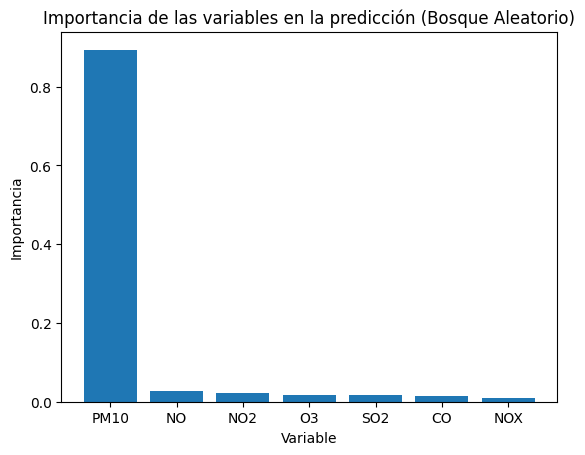

In [124]:
pyplot.bar(variables[indices], importancias[indices])
pyplot.title("Importancia de las variables en la predicción (Bosque Aleatorio)")
pyplot.xlabel("Variable")
pyplot.ylabel("Importancia")
pyplot.show()

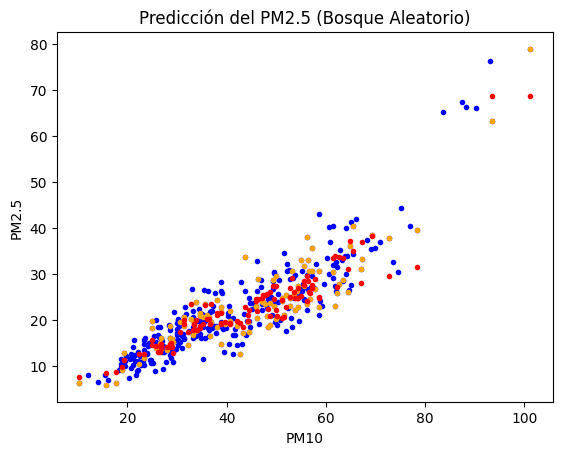

In [133]:
y_plot = modelo.predict(X)

pyplot.scatter(X[:, indices[0]], y, color="blue", marker=".")
pyplot.scatter(X_test[:, indices[0]], y_test, color="orange", marker=".")
pyplot.scatter(X_test[:, indices[0]], y_pred, color="red", marker=".")
pyplot.title("Predicción del PM2.5 (Bosque Aleatorio)")
pyplot.xlabel(variables[indices[0]])
pyplot.ylabel("PM2.5")
pyplot.show()

Text(0.5, 0, 'Predicción (PM2.5)')

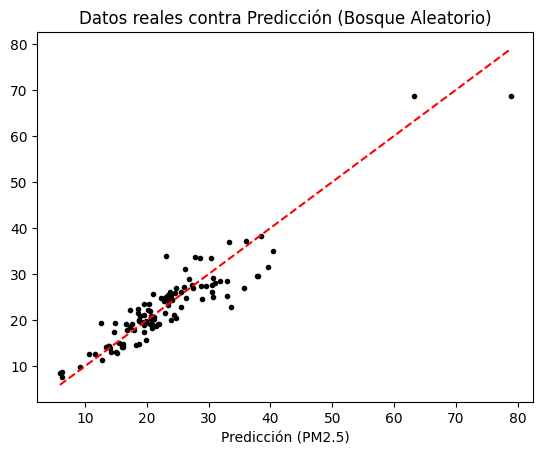

In [137]:
pyplot.scatter(y_test, y_pred, marker=".", color="black")
pyplot.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
pyplot.title("Datos reales contra Predicción (Bosque Aleatorio)")
pyplot.xlabel("Datos reales (PM2.5)")
pyplot.xlabel("Predicción (PM2.5)")

In [138]:
rama["PM25p"] = modelo.predict(X)

rama.head()

,CO,NO,NO2,NOX,O3,PM10,PM25,SO2,PM25p
0,0.642419,12.617143,22.363946,35.441905,38.940387,93.458586,63.278607,4.616041,68.718933
1,0.533982,18.812081,29.930827,49.379195,23.565789,63.889813,33.844221,7.147321,33.268069
2,0.715211,33.603041,38.135542,72.822635,24.922164,65.099404,27.566586,4.555878,27.812305
3,0.656344,28.825127,35.659542,65.322581,31.628838,66.979879,30.995074,3.610370,28.064690
4,0.547734,18.575552,32.806354,52.078098,36.803170,69.781676,35.745843,5.655977,34.695863


In [139]:
rama.index = pandas.to_datetime(pandas.read_csv("rama_2019.csv")["fecha"])
rama[["PM25", "PM25p"]].head()

,PM25,PM25p
fecha,,
2019-01-01,63.278607,68.718933
2019-01-02,33.844221,33.268069
2019-01-03,27.566586,27.812305
2019-01-04,30.995074,28.064690
2019-01-05,35.745843,34.695863


Text(0.5, 1.0, 'Predicción del PM2.5 (Bosque Aleatorio)')

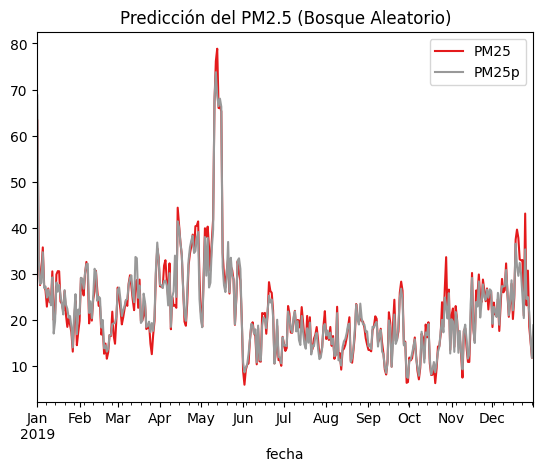

In [149]:
rama[["PM25", "PM25p"]].plot(cmap="Set1")
pyplot.title("Predicción del PM2.5 (Bosque Aleatorio)")